In [232]:
import numpy as np
import matplotlib.pyplot as plt
import random

# PageRank


## **Introduction** ##


### **PageRank (PR)** is an algorithm used by Google Search to rank web pages in their search engine results. ###

### It is named after both the term "web page" and co-founder [Larry Page](https://en.wikipedia.org/wiki/Larry_Page). ###

### PageRank is a way of measuring the importance of website pages. ###



### According to Google: ###


#### _PageRank works by counting the number and quality of links to a page to determine a rough estimate of how important the website is._ ####

#### _The underlying assumption is that more important websites are likely to receive more links from other websites._ ####




## **Algorithm Description** ## 


### **PageRank** is a link analysis algorithm that assigns a numerical weighting to each element of a hyperlinked set of documents, with the purpose of measuring its relative importance within the set. ###
### The algorithm may be applied to any collection of entities with reciprocal quotations and references. ###
### The numerical weight that it assigns to any given element $E$ is referred to as the _PageRank_ of $E$ and denoted by $PR(E)$. ###
### A _PageRank_ results from a mathematical algorithm based on the [Webgraph](https://en.wikipedia.org/wiki/Webgraph), created by all World Wide Web pages as nodes and hyperlinks as edges. ###
### The rank value indicates an importance of a particular page. A hyperlink to a page counts as a vote of support. ###
### The _PageRank_ of a page is defined recursively and depends on the number and PageRank metric of all pages that link to it ("incoming links"). ###
### A page that is linked to by many pages with high _PageRank_ receives a high rank itself. ###




## **Algorithm** ##

### Let's assume the internet consists of only 4 web pages. **A**, **B**, **C**, **D**. ###

### Links from a page to itself are ignored. Multiple outbound links from one page to another page are treated as a single link. ##
### 1.Define the links. ###
### A → B, C ###
### B → C ###
### C → A ###
### D → C ###

### 2. Start with equal rank. ###
### At the beginning every page is equally important. ###
### $PR(A)$ = $PR(D)$ = $PR(C)$ = $PR(D)$ = $0.25$ ###

### 3. Distribute ranks through links. ###
### Page **A** links to **B** and **C** so each gets 0.25/2 = 0.125 ###
### Page **B** links to **C** so it gets 0.25 ###
### Page **C** links to **A** so it gets 0.25 ###
### Page **D** links to **C** so it gets 0.25 ###

### 4. Add contributions. ###
### $PR(A)$ = 0.25 ###
### $PR(B)$ = 0.125 ###
### $PR(C)$ = 0.125 + 0.25 + 0.25 ###
### $PR(D)$ = 0 ###

### In the general case, the PageRank value for any page _u_ can be expressed as:  ### 
### $PR(u) = \displaystyle \sum_{v \in B(u)} \frac{PR(v)}{L(v)} $ ###

### 5. After several repeats of the process. ###
### **A** ~ 0.372 ###
### **B** ~ 0.195 ###
### **C** ~ 0.394 ###
### **D** ~ 0.037 ###

### 6. Add damping factor (0.85) ### 
### $PR(pi) = \frac{1-d}{N} + d \displaystyle \sum_{pj \in M(pi)} \frac{PR(pj)}{L(pj)} $ ###
### Which means: ###
### 85% follow links ### 
### 15% randomly jump to another page ### 
### This prevents pages like D from getting stuck at zero. ###




#### Define the _pagerank_ function to calculate the _PageRank_ vector ####

In [233]:
def pagerank(transition_matrix, damping_factor: float = 0.85):
    """PageRank algorithm. Returns a vector with ranking of nodes (pages).

    Parameters
    ----------
    transition_matrix : numpy array, mandatory
        transition matrix where M_i,j represents the link from 'j' to 'i', such that for all 'j'
        sum(i, M_i,j) = 1
    damping_factor : float, optional
        damping factor, by default 0.85

    Returns
    -------
    numpy array
        a vector of ranks such that v_i is the i-th rank from [0, 1],
        
    """
    num_pages = transition_matrix.shape[1]
    
    # We assume all pages are equally important
    # Fixes also dangling nodes (pages with no outgoing links)
    rank_vector = np.ones(num_pages) / num_pages

    # Applying the damping factor
    # Represents the probability a user follows a link
    damped_matrix = damping_factor * transition_matrix

    # Page rank received from incoming links
    link_contribution = damped_matrix @ rank_vector

    # Probability of randomly jumping to any page.
    # Adds small probability to every page
    teleportation_probability = (1 - damping_factor) / num_pages

    # First rank update
    new_rank_vector = link_contribution + teleportation_probability
    
    # Algorithm runs until convergence
    # w - old rank
    # v - new rank
    # Repeating until difference is smaller than 1e-10
    while np.linalg.norm(rank_vector - new_rank_vector) >= 1e-10:
        # Update old vector
        rank_vector = new_rank_vector

        # Recalculate rank
        new_rank_vector = damped_matrix @ rank_vector + (1 - damping_factor) / num_pages
    
    # Return final PageRank vector
    return new_rank_vector



#### Let's first test with an already transformed transition Markov matrix instead of a real Webgraph matrix (which will be shown later), so we can see the simplified version of the algorithm. ####

In [234]:
M = np.array([
    [0, 0, 1, 0],      # A
    [0.5, 0, 0, 0],    # B
    [0.5, 1, 0, 1],    # C
    [0, 0, 0, 0]])     # D

#### Get the _PageRank_ result vector ####

In [235]:
page_rank_result = pagerank(M)

#### Show the _PageRank_ result vector ####

In [236]:
page_rank_result

array([0.37252685, 0.19582391, 0.39414924, 0.0375    ])

#### Define the _is_valid_pagerank_ function to check if the result _PageRank_ vector is valid ####

In [237]:
def is_valid_pagerank(v, tol = 1e-10):
    """
    Check if a vector v is a valid PageRank vector.

    Parameters
    ----------
    v : numpy array
        The PageRank vector to check.
    tol : float
        Tolerance for sum to 1 (default 1e-10).

    Returns
    -------
    bool
        True if v is a valid PageRank vector, False otherwise.
    """
    v = np.asarray(v)

    # 1. All entries non-negative
    if np.any(v < 0):
        return False

    # 2. Sum close to 1
    if not np.isclose(np.sum(v), 1, atol=tol):
        return False

    # 3. Not empty
    if v.size == 0:
        return False

    return True

#### Checking if the result is a valid _PageRank_ vector ####

In [238]:
is_valid_pagerank(page_rank_result)

True

#### Define a function which generates a random Webgraph adjacency matrix so we can see what happens with more pages ####

In [239]:
def generate_webgraph_matrix(num_pages: int, max_links_per_page: int = 10):
    """
    Generates a random webgraph adjacency matrix (0/1 links).

    Parameters
    ----------
    num_pages : int
        Number of pages (nodes) in the graph.
    max_links_per_page : int
        Maximum number of outgoing links per page.

    Returns
    -------
    numpy.ndarray
        Adjacency matrix A where A[i, j] = 1 if page j links to page i, else 0.
        Columns represent source pages, rows represent target pages.
    """
    
    # Initialize empty adjacency matrix
    webgraph_matrix = np.zeros((num_pages, num_pages), dtype = int)

    for j in range(num_pages):
        # Random number of outgoing links for page j
        num_links = random.randint(1, max_links_per_page)

        # Pick unique target pages
        targets = random.sample(range(num_pages), num_links)

        # Remove self-links if not allowed
        targets = [t for t in targets if t != j]

        # Ensure at least one outgoing link
        if len(targets) == 0:
            targets = [random.choice([x for x in range(num_pages) if x != j])]

        # Add links
        for i in targets:
            webgraph_matrix[i, j] = 1

    return webgraph_matrix

#### Generate a Webgraph matrix programmatically so we can play with the parameters #### 

In [240]:
generated_webgraph_matrix = generate_webgraph_matrix(500, max_links_per_page=3)

#### Show the generated Webgraph matrix ####

In [241]:
generated_webgraph_matrix

array([[0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

#### Transform the Webgraph matrix to a Markov transition matrix ####

In [242]:
transition_matrix = generated_webgraph_matrix / generated_webgraph_matrix.sum(axis=0)

#### Show the transformed Markov transition matrix ####

In [243]:
transition_matrix

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.33333333, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

#### Define the _is_markov_matrix_ function to check if the input matrix is a valid Markov chain matrix ####

In [244]:
def is_markov_matrix(matrix):
    """
    Checks if the given matrix is a valid Markov chain matrix.
    A valid Markov matrix has:
    - Each column sums to 1
    - All entries are non-negative
    """
    matrix = np.array(matrix)
    
    # Check if square
    if matrix.shape[0] != matrix.shape[1]:
        return False
    
    # Check non-negative entries
    if np.any(matrix < 0):
        return False
    
    # Check column sums
    col_sums = matrix.sum(axis=0)
    return np.allclose(col_sums, 1.0)

#### Check if the matrix is a Markov matrix ####


In [245]:
is_markov_matrix(transition_matrix)

True

#### Compute _PageRank_ result vector ####

In [246]:
pagerank_result_vector = pagerank(transition_matrix)

#### Show the _PageRank_ result ####

In [247]:
pagerank_result_vector

array([0.0009436 , 0.00056735, 0.00146305, 0.0051008 , 0.0004275 ,
       0.0003    , 0.00411283, 0.0003    , 0.00444301, 0.00423076,
       0.0003    , 0.00229614, 0.00237087, 0.00099169, 0.00108755,
       0.00085055, 0.00211586, 0.00087204, 0.00076331, 0.00226993,
       0.00291024, 0.00119003, 0.00411946, 0.00124301, 0.00067676,
       0.00452675, 0.00358876, 0.00415055, 0.00291165, 0.00186714,
       0.00132973, 0.00096218, 0.0004275 , 0.00069065, 0.00200261,
       0.00173783, 0.00117845, 0.00175335, 0.00128956, 0.00130399,
       0.00135065, 0.00655164, 0.00096513, 0.01019788, 0.00509292,
       0.0003    , 0.0003    , 0.0003    , 0.0006269 , 0.00148322,
       0.00180584, 0.0004275 , 0.00161444, 0.00093923, 0.0005125 ,
       0.00430346, 0.00373117, 0.00161718, 0.00119166, 0.00509792,
       0.00478524, 0.00130762, 0.0003    , 0.00091918, 0.0003    ,
       0.00160312, 0.00156896, 0.0003    , 0.00055648, 0.00141154,
       0.0003    , 0.00459696, 0.00215189, 0.0022458 , 0.00112

### Display a histogram with the _PageRank_ result vector ###

#### We can observe _PageRank_ result distribution is skewed, few pages have high PageRank and many with tiny values ####

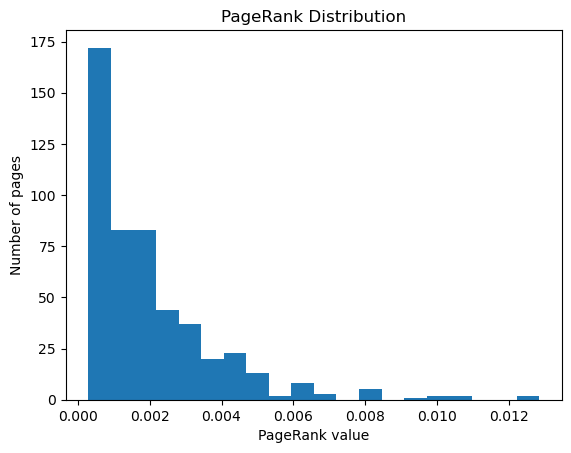

In [248]:
plt.hist(pagerank_result_vector, bins=20)

plt.title("PageRank Distribution")
plt.xlabel("PageRank value")
plt.ylabel("Number of pages")

plt.show()